# Regresie — Prezicerea Numarului de Goluri dintr-un Meci La Liga

## Definirea problemei

Acest notebook abordeaza o problema de **regresie**: dat fiind un meci din La Liga (campionatul spaniol de fotbal), modelul trebuie sa prezica **numarul total de goluri marcate** (goluri echipa gazda + goluri echipa oaspete).

**Variabila tinta:** `TotalGoals` — numarul total de goluri marcate intr-un meci (valori intregi, intervalul tipic: 0–8)

**Variabile de intrare (features):**
- `HomeTeam_Enc`, `AwayTeam_Enc` — echipele encodate numeric
- `HomeGoalsAvg5`, `AwayGoalsAvg5` — media golurilor marcate in ultimele 5 meciuri
- `HomeConcededAvg5`, `AwayConcededAvg5` — media golurilor primite in ultimele 5 meciuri
- `H2H_HomeGoals`, `H2H_AwayGoals` — media golurilor in ultimele 3 confruntari directe
- `FormDiff`, `DefenseDiff`, `H2HDiff` — diferente derivate din features-urile de mai sus
- `HomeAdvantage` — variabila constanta (1) care marcheaza avantajul terenului propriu

**Relevanta practica:** Prezicerea numarului de goluri este utila in analiza tactica, pariuri sportive (over/under), simulari de meciuri si planificarea strategica a cluburilor. Un model bun de ML poate captura pattern-uri istorice pe care statistica traditionala le ignora.

Am ales La Liga deoarece este unul dintre cele mai studiate campionate din lume, cu date consistente pe mai multi ani, oferind suficiente exemple pentru antrenarea si validarea modelelor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.pipeline import Pipeline

C:\Users\Denis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Incarcarea datelor

Incarcam datasetul `LaLiga_Matches.csv` care contine meciurile din La Liga. Verificam structura generala, tipurile de coloane si primele randuri pentru a intelege formatul datelor.

### Notatii coloane:
| Coloana | Semnificatie |
|---------|-------------|
| FTHG | Full Time Home Goals |
| FTAG | Full Time Away Goals |
| FTR | Full Time Result (H/A/D) |
| HTHG | Half Time Home Goals |
| HTAG | Half Time Away Goals |
| HTR | Half Time Result |

In [2]:
df = pd.read_csv("LaLiga_Matches.csv")

## Explorarea structurii datelor

Verificam dimensiunile datasetului, tipurile de date si statisticile descriptive pentru a obtine o imagine de ansamblu asupra distributiei valorilor.

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 11664 entries, 0 to 11663
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    11664 non-null  str    
 1   Date      11664 non-null  str    
 2   HomeTeam  11664 non-null  str    
 3   AwayTeam  11664 non-null  str    
 4   FTHG      11664 non-null  int64  
 5   FTAG      11664 non-null  int64  
 6   FTR       11664 non-null  str    
 7   HTHG      11662 non-null  float64
 8   HTAG      11662 non-null  float64
 9   HTR       11662 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 1.3 MB


,FTHG,FTAG,HTHG,HTAG
count,11664.000000,11664.000000,11662.000000,11662.000000
mean,1.546639,1.119084,0.686932,0.484823
std,1.300203,1.110989,0.840816,0.698339
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000
max,10.000000,8.000000,6.000000,6.000000


## Verificarea valorilor lipsa

Identificam daca exista valori lipsa in dataset si in ce coloane apar acestea. O cunoastere clara a lacunelor din date este esentiala inainte de orice preprocesare.

In [4]:
df.isnull().values.any()

np.True_

### Randuri cu valori lipsa

Afisam randurile cu valori lipsa pentru a intelege contextul — este vorba de meciuri specifice sau de un pattern sistematic?

In [5]:
df[df.isnull().any(axis=1)]

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR
136,1995-96,19-11-1995,Ath Bilbao,La Coruna,1,0,H,NaN,NaN,NaN
1472,1998-99,10-01-1999,Valladolid,Betis,0,3,A,NaN,NaN,NaN


### Tratarea valorilor lipsa

Completam manual valorile lipsa pentru 2 meciuri (indexii 136 si 1472) cu valori implicite plauzibile:
- Goluri la pauza: 0 (meci fara goluri la pauza)
- Rezultat la pauza: 'D' (egalitate)

Aceasta abordare conserva randurile in loc sa le elimine, pastrand maximul de date disponibile.

In [6]:
df.loc[136,'HTHG'] = 0
df.loc[1472,'HTHG'] = 0
df.loc[136,'HTAG'] = 0
df.loc[1472,'HTAG'] = 0
df.loc[136,'HTR'] = 'D'
df.loc[1472,'HTR'] = 'D'
df.isnull().values.any()

np.False_

## Analiza exploratorie a datelor (EDA)

### Distributia rezultatelor

Vizualizam distributia rezultatelor finale (H = victorie gazda, A = victorie oaspete, D = egalitate) pentru a intelege echilibrul claselor si caracteristicile generale ale campionatului.

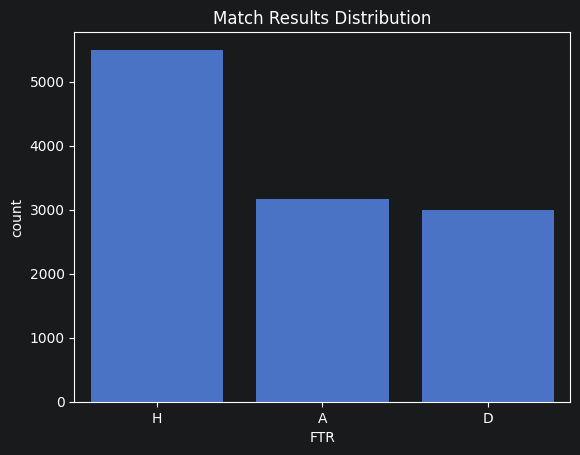

In [7]:
sns.countplot(x='FTR', data=df)
plt.title("Match Results Distribution")
plt.show()

### Matricea de corelatie

Analizam corelatiile dintre golurile marcate la pauza si golurile finale. O corelatie ridicata intre HTHG si FTHG confirma intuitia ca echipele care marcheaza la pauza tind sa castige meciul — aceasta relatie justifica includerea statisticilor de forma in features.

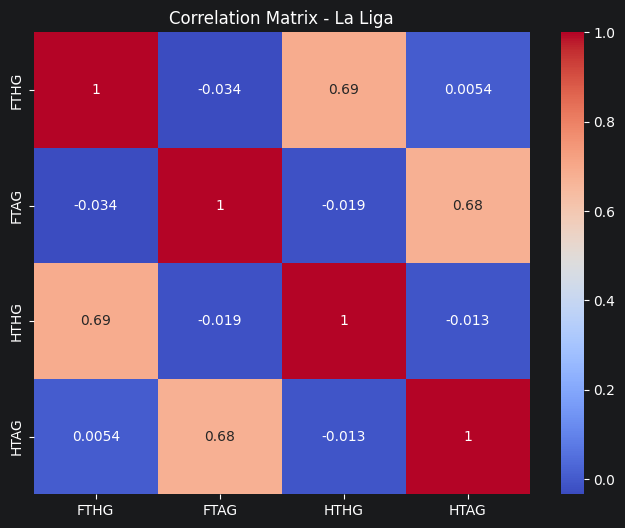

In [8]:
corr = df[['FTHG', 'FTAG', 'HTHG', 'HTAG']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix - La Liga")
plt.show()

### Detectarea outlierilor

Folosim un boxplot pentru a vizualiza distributia totalului de goluri pe meci si a identifica scoruri neobisnuite. Outlierii reprezinta meciuri cu scor spectaculos (6+ goluri) care sunt rare dar reale — nu ii eliminam deoarece fac parte din distributia naturala a datelor.

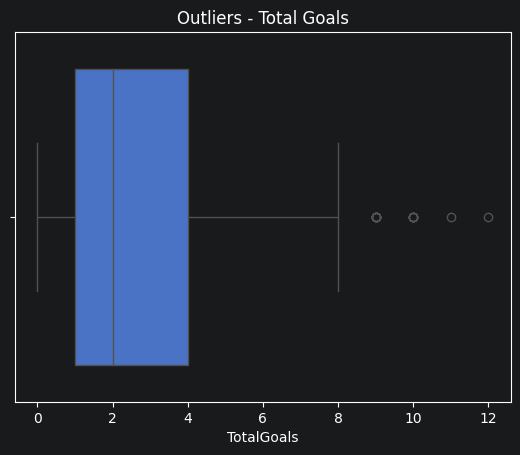

In [9]:
df['TotalGoals'] = df['FTHG'] + df['FTAG']
sns.boxplot(x=df['TotalGoals'])
plt.title("Outliers - Total Goals")
plt.show()

## Feature Engineering si preprocesarea datelor

Construim features noi care captureaza **forma recenta** a echipelor si **istoricul direct** dintre ele:

- **Rolling averages pe 5 meciuri** pentru goluri marcate si primite — captura forma actuala a echipei
- **Head-to-head pe 3 meciuri** — captura dinamica specifica dintre cele doua echipe
- **Diferente derivate** (FormDiff, DefenseDiff, H2HDiff) — compara direct cele doua echipe

> **Important:** toate calculele folosesc `.shift()` inainte de `.rolling()` pentru a evita data leakage — fiecare meci foloseste doar informatii din meciurile *anterioare*.

Aplicam `StandardScaler` pentru modelele sensibile la scala (SVR, KNN, LinearRegression) si impartim datele 75/25.

In [10]:
le = LabelEncoder()
df['HomeTeam_Enc'] = le.fit_transform(df['HomeTeam'])
df['AwayTeam_Enc'] = le.fit_transform(df['AwayTeam'])
df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['HomeGoalsAvg5'] = df.groupby('HomeTeam')['FTHG'].transform(
    lambda x: x.shift().rolling(5).mean()
)
df['AwayGoalsAvg5'] = df.groupby('AwayTeam')['FTAG'].transform(
    lambda x: x.shift().rolling(5).mean()
)
df['HomeConcededAvg5'] = df.groupby('HomeTeam')['FTAG'].transform(
    lambda x: x.shift().rolling(5).mean()
)
df['AwayConcededAvg5'] = df.groupby('AwayTeam')['FTHG'].transform(
    lambda x: x.shift().rolling(5).mean()
)
df['H2H_HomeGoals'] = df.groupby(['HomeTeam', 'AwayTeam'])['FTHG'].transform(
    lambda x: x.shift().rolling(3).mean()
)
df['H2H_AwayGoals'] = df.groupby(['HomeTeam', 'AwayTeam'])['FTAG'].transform(
    lambda x: x.shift().rolling(3).mean()
)
df['FormDiff'] = df['HomeGoalsAvg5'] - df['AwayGoalsAvg5']
df['DefenseDiff'] = df['AwayConcededAvg5'] - df['HomeConcededAvg5']
df['H2HDiff'] = df['H2H_HomeGoals'] - df['H2H_AwayGoals']
df['HomeAdvantage'] = 1
df = df.dropna()
features = [
    'HomeTeam_Enc',
    'AwayTeam_Enc',
    'HomeGoalsAvg5',
    'AwayGoalsAvg5',
    'HomeConcededAvg5',
    'AwayConcededAvg5',
    'H2H_HomeGoals',
    'H2H_AwayGoals',
    'FormDiff',
    'DefenseDiff',
    'HomeAdvantage',
    'H2HDiff'
]
X = df[features]
y = df['TotalGoals']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Antrenarea si compararea modelelor de baza

Antrenam 9 algoritmi de regresie cu hiperparametrii impliciti pe datele scalate si le evaluam performanta pe setul de test.

**Metrici folosite:**
- **MSE** (Mean Squared Error) — penalizeaza puternic erorile mari
- **MAE** (Mean Absolute Error) — eroarea medie absoluta in goluri
- **RMSE** (Root MSE) — interpretabil in aceeasi unitate ca tinta (goluri)
- **R²** — procentul din varianta datelor explicat de model (1.0 = perfect)

Afisam tabelul comparativ si graficul Real vs. Prezis pentru cel mai bun model.


Training LinearRegression...
MSE: 2.7934470469737223
MAE: 1.3359755380299172
RMSE: 1.6713608368553219
R2: 0.02399359419085756

Training DecisionTree...
MSE: 5.744525547445256
MAE: 1.8738269030239834
RMSE: 2.396773987560207
R2: -1.0070878876028257

Training RandomForest...
MSE: 2.9042101407716374
MAE: 1.3664077163712203
RMSE: 1.7041743281635355
R2: -0.014706079458270516

Training SVR...
MSE: 2.918963201897332
MAE: 1.3535376006920934
RMSE: 1.708497352031115
R2: -0.01986067230425692

Training KNN...
MSE: 3.426757038581856
MAE: 1.4741397288842544
RMSE: 1.8511501934153956
R2: -0.19727947749385777

Training GaussianProcess...
MSE: 5.550536564048102
MAE: 1.8784164821614502
RMSE: 2.3559576745026853
R2: -0.939309802939599

Training XGBoost...
MSE: 3.236410617828369
MAE: 1.4354183673858643
RMSE: 1.7990026731020632
R2: -0.1307739019393921

Training CatBoost...
MSE: 2.892626666886729
MAE: 1.3614136754620885
RMSE: 1.7007723736252094
R2: -0.010658913171212703
| Model            |     MSE |     MAE 

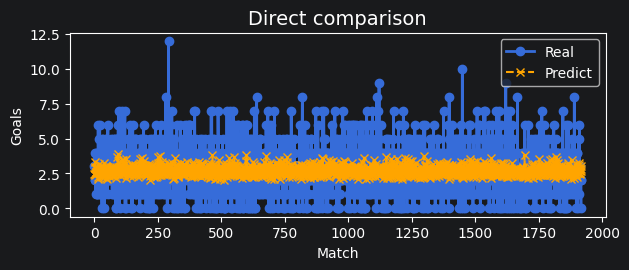

In [11]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "GaussianProcess": GaussianProcessRegressor(),
    "XGBoost": XGBRegressor(verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0),
}
results = []
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })
    print(f"MSE: {mse}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")
df_results = pd.DataFrame(results).sort_values(by="R2", ascending=False).head(5)
print(df_results.to_markdown(index=False))
best_model_name = df_results.iloc[0]['Model']
best_model = models[best_model_name]
y_best_pred = best_model.predict(X_test_scaled)
plt.figure()
plt.subplot(2, 1, 2)
plt.plot(y_test.values, label='Real', marker='o', linewidth=2)
plt.plot(y_best_pred, label='Predict', marker='x', linestyle='--', color='orange')
plt.title('Direct comparison', fontsize=14)
plt.xlabel('Match')
plt.ylabel('Goals')
plt.legend()
plt.tight_layout()
plt.show()

## Ajustarea hiperparametrilor (GridSearchCV)

Selectam primele 5 modele si optimizam hiperparametrii cu `GridSearchCV` (cv=3, scoring='r2').

**Decizie de design cheie:** modelele sensibile la scala (SVR, KNN, LinearRegression) sunt integrate intr-un `Pipeline` cu `StandardScaler`. Astfel, scaler-ul este antrenat exclusiv pe fold-ul de antrenare din fiecare iteratie a cross-validarii — se previne data leakage si evaluarea este corecta.

Parametrii cu prefix `model__` sunt necesari cand modelul e in Pipeline (ex: `model__C` in loc de `C`).

In [12]:
NEEDS_SCALING = {"SVR", "KNN", "LinearRegression"}
param_grids = {
    "CatBoost": {'iterations': [100, 200], 'depth': [4, 6], 'learning_rate': [0.05, 0.1]},
    "SVR": {'model__C': [0.1, 1, 10], 'model__kernel': ['rbf']},
    "LinearRegression": {},
    "XGBoost": {'n_estimators': [100, 200], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]},
    "RandomForest": {'n_estimators': [100, 200], 'max_depth': [10, 20]}
}
optimized_results = []
best_estimators = {}
for name in df_results['Model']:
    print(f"Optimizing {name}...")
    model_instance = models[name]
    grid = param_grids.get(name, {})
    if name in NEEDS_SCALING:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model_instance)
        ])
        if grid:
            grid_search = GridSearchCV(pipeline, grid, cv=3, scoring='r2', n_jobs=-1)
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"  Best params: {grid_search.best_params_}")
        else:
            best_model = pipeline.fit(X_train, y_train)
        preds = best_model.predict(X_test)
    else:
        if grid:
            grid_search = GridSearchCV(model_instance, grid, cv=3, scoring='r2', n_jobs=-1)
            grid_search.fit(X_train, y_train)
            best_model = grid_search.best_estimator_
            print(f"  Best params: {grid_search.best_params_}")
        else:
            best_model = model_instance.fit(X_train, y_train)
        preds = best_model.predict(X_test)
    best_estimators[name] = best_model
    optimized_results.append({
        "Model": name,
        "MSE": mean_squared_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds)
    })
df_final = pd.DataFrame(optimized_results).sort_values(by="R2", ascending=False)
print("\nOptimised")
print(df_final.to_markdown(index=False))

Optimizing LinearRegression...
Optimizing CatBoost...
  Best params: {'depth': 4, 'iterations': 100, 'learning_rate': 0.05}
Optimizing RandomForest...
  Best params: {'max_depth': 10, 'n_estimators': 200}
Optimizing SVR...
  Best params: {'model__C': 0.1, 'model__kernel': 'rbf'}
Optimizing XGBoost...
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Optimised
| Model            |     MSE |    RMSE |          R2 |
|:-----------------|--------:|--------:|------------:|
| CatBoost         | 2.76962 | 1.66422 |  0.0323179  |
| XGBoost          | 2.77892 | 1.66701 |  0.0290681  |
| RandomForest     | 2.7893  | 1.67012 |  0.0254423  |
| LinearRegression | 2.79345 | 1.67136 |  0.0239936  |
| SVR              | 2.87079 | 1.69434 | -0.00302797 |


## Curbele de invatare

Analizam comportamentul celor 5 modele optimizate in functie de cantitatea de date de antrenare:

- **Overfitting:** scorul de antrenare (rosu) mult mai mare decat cel de validare (verde) — modelul memoreaza datele
- **Underfitting:** ambele scoruri mici — modelul este prea simplu
- **Generalizare buna:** scorurile converg la valori ridicate — modelul invata pattern-uri reale

Diferenta mica si stabila intre cele doua curbe indica un model bine calibrat.

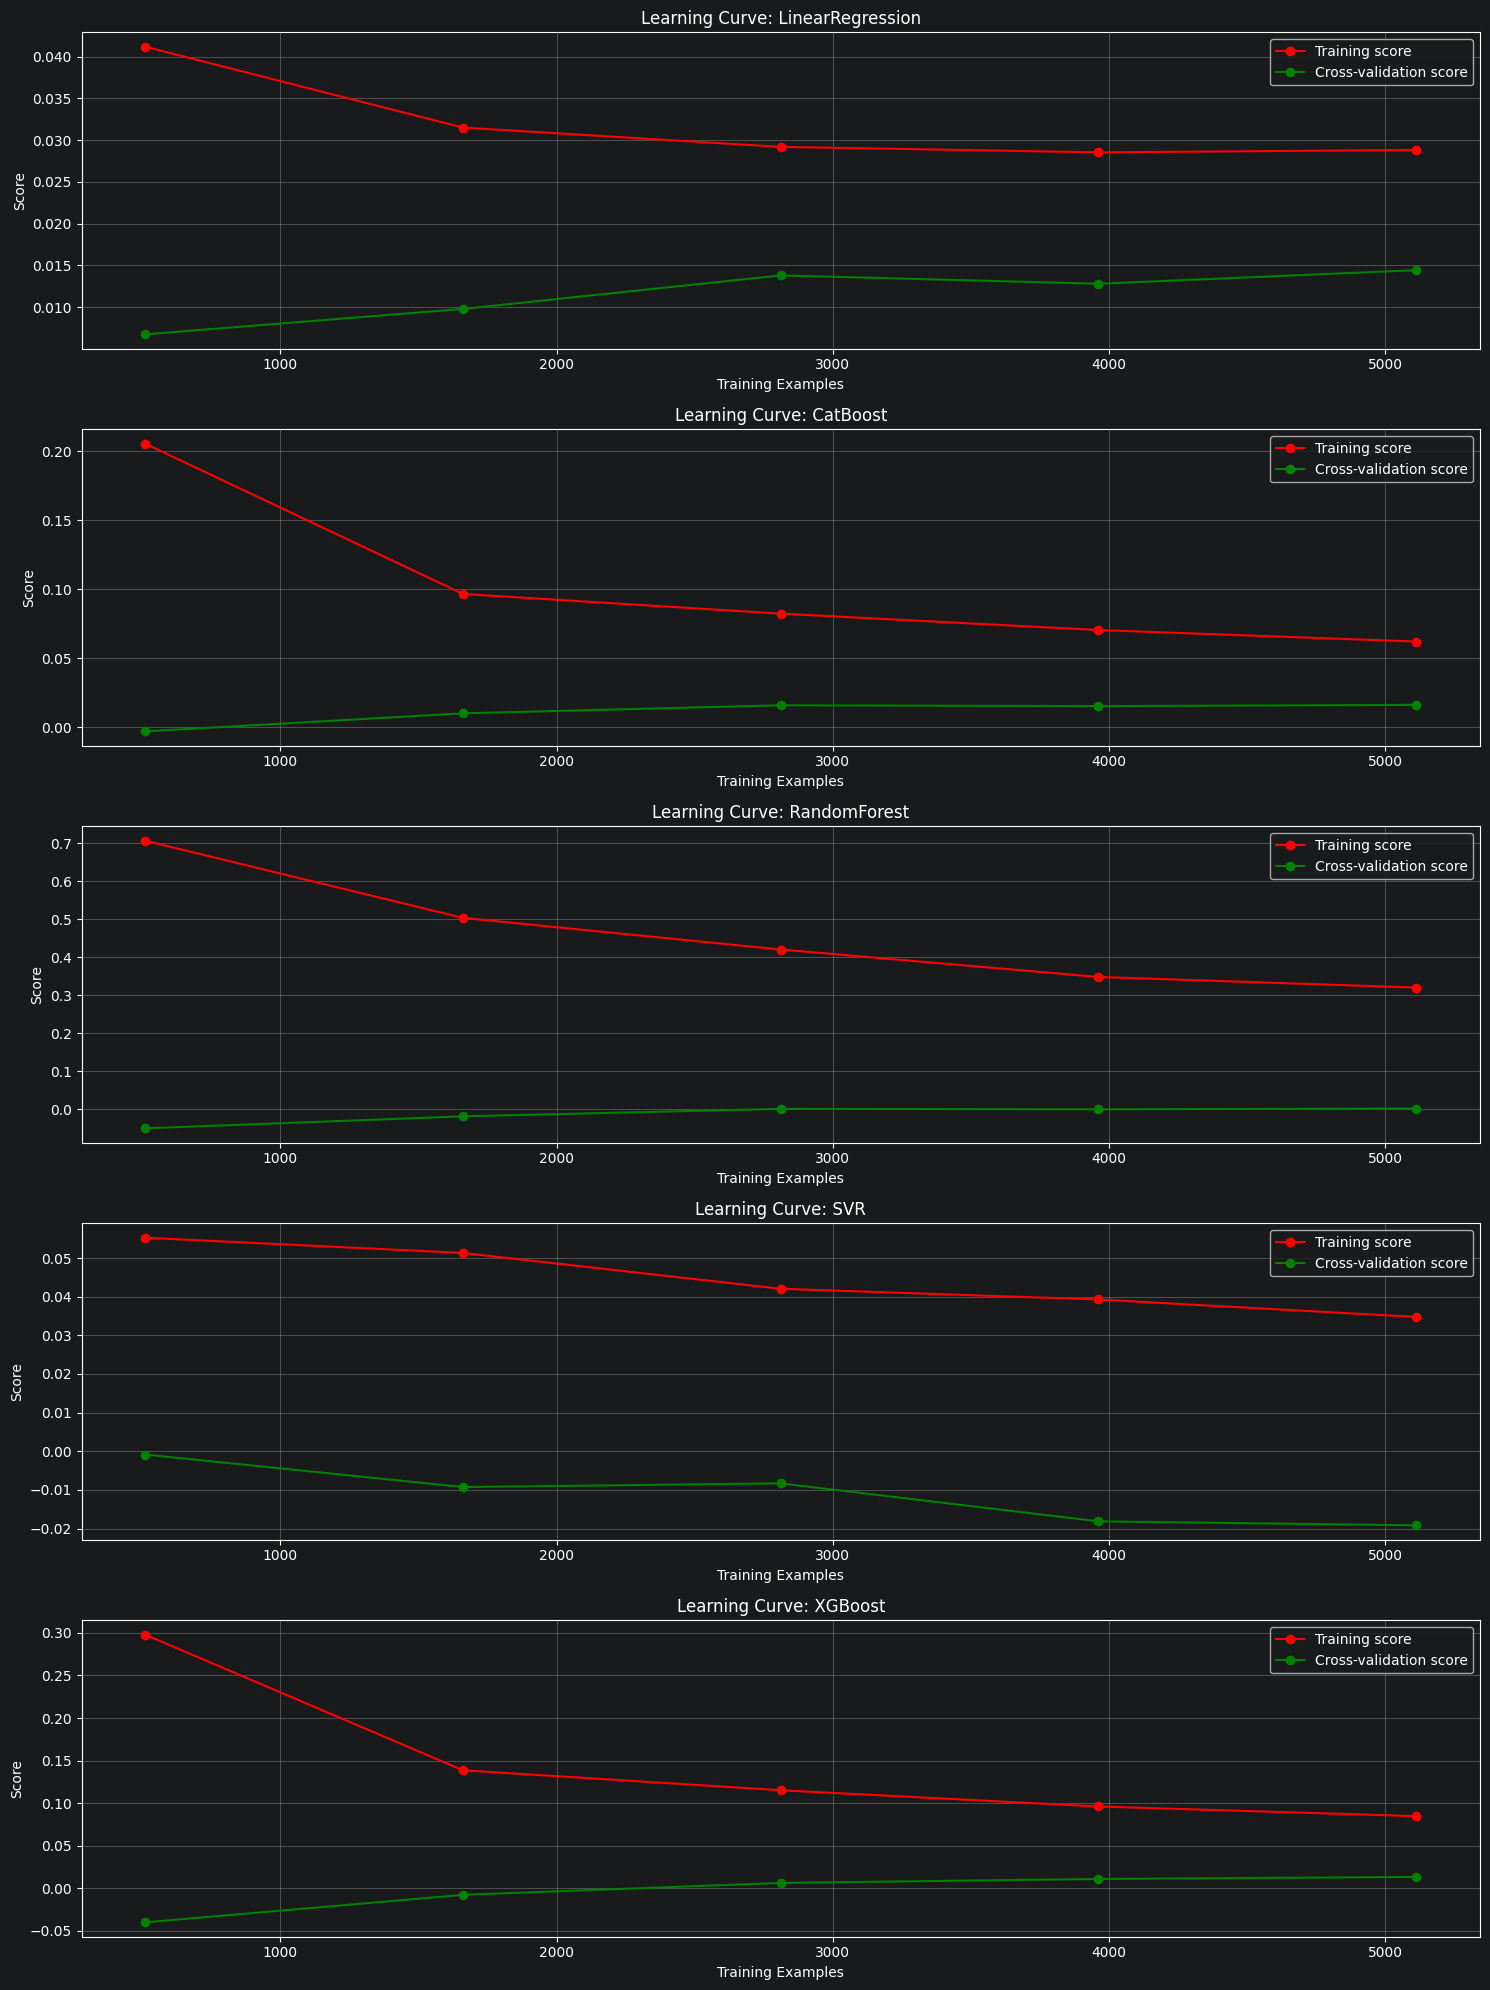

In [13]:
plt.figure(figsize=(15, 20))
for i, (name, model) in enumerate(best_estimators.items(), 1):
    plt.subplot(5, 1, i)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=3, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Training Examples")
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
plt.tight_layout()
plt.show()

## Explicabilitatea modelelor (SHAP)

Interpretam predictiile celor mai bune 3 modele folosind SHAP (SHapley Additive exPlanations) — o metoda bazata pe teoria jocurilor care atribuie fiecarui feature contributia sa la fiecare predictie.

**Grafice globale (comportament general al modelului):**
- **Summary plot** — fiecare punct e un sample; culoarea = valoarea featurelui, pozitia pe axa X = impactul SHAP
- **Bar plot** — importanta medie absoluta a fiecarei caracteristici

**Grafice locale (explicatie pentru o predictie individuala):**
- **Waterfall plot** — cum ajunge modelul de la valoarea de baza la predictia finala pentru Sample 0

**Scatter plots** — relatia dintre valorile unui feature si impactul sau SHAP:
- Panta pozitiva: valori mari ale featurelui **cresc** predictia (mai multe goluri)
- Panta negativa: valori mari **scad** predictia


=== SHAP ANALYSIS FOR: CatBoost ===


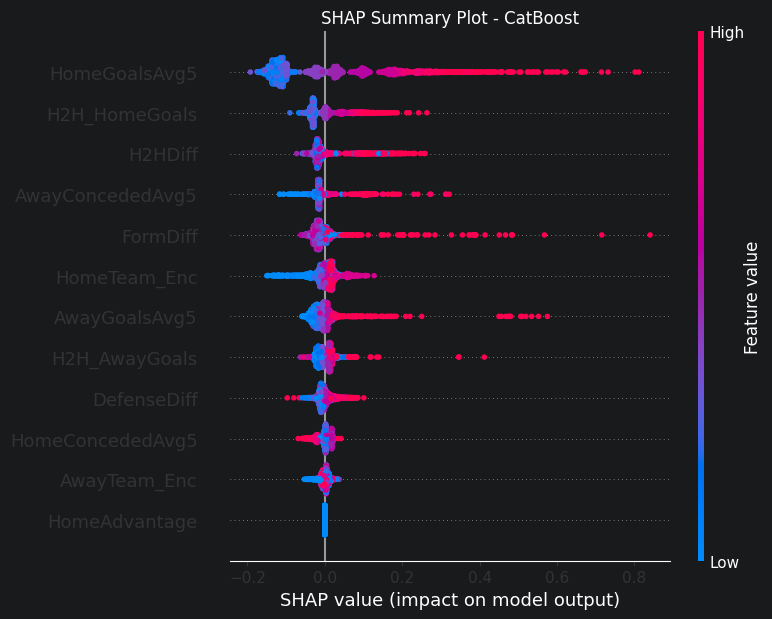

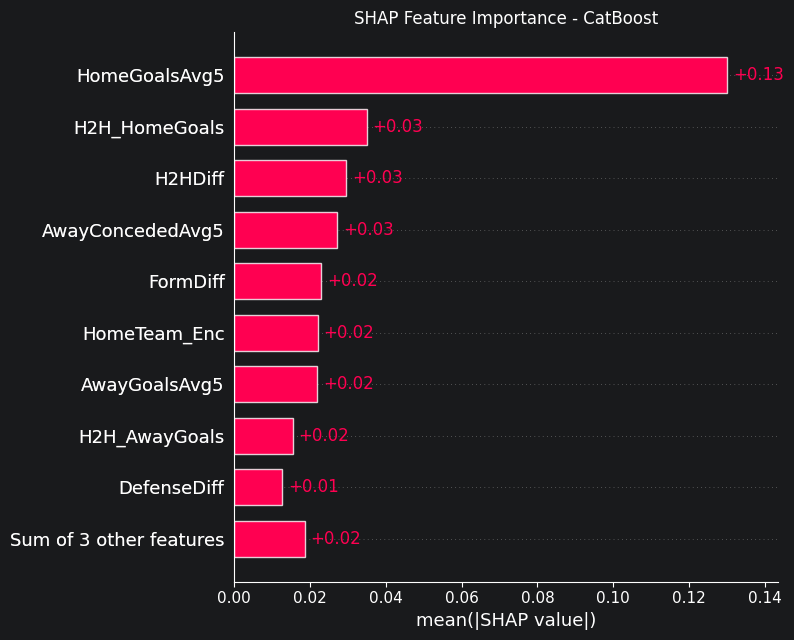

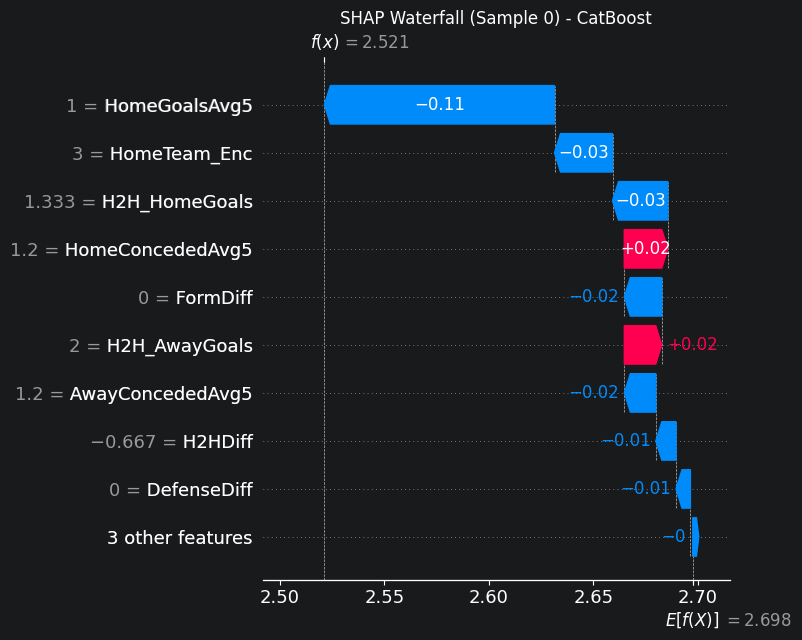

<Figure size 800x500 with 0 Axes>

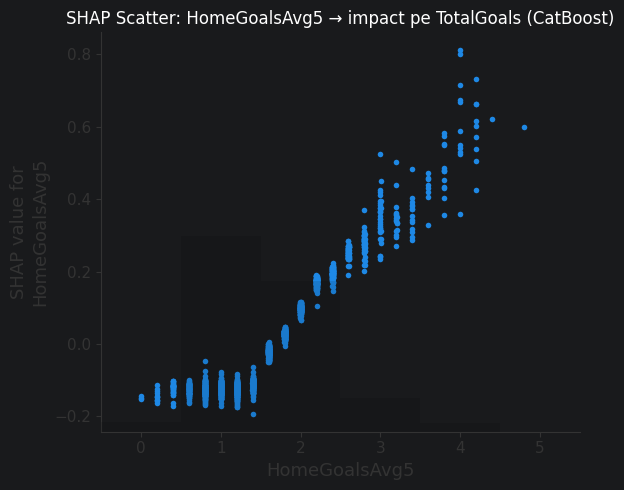

<Figure size 800x500 with 0 Axes>

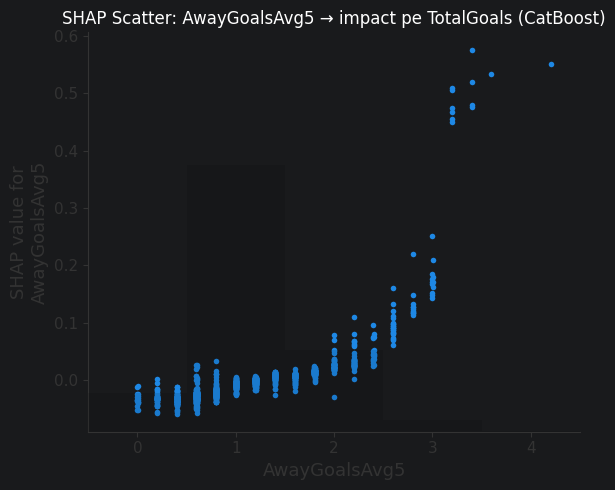

<Figure size 800x500 with 0 Axes>

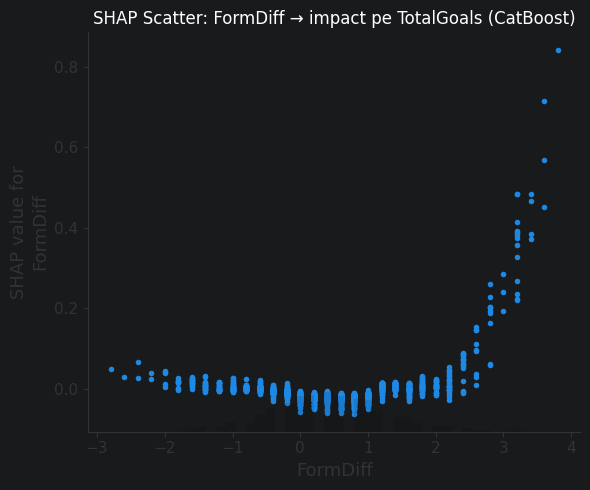


=== SHAP ANALYSIS FOR: XGBoost ===


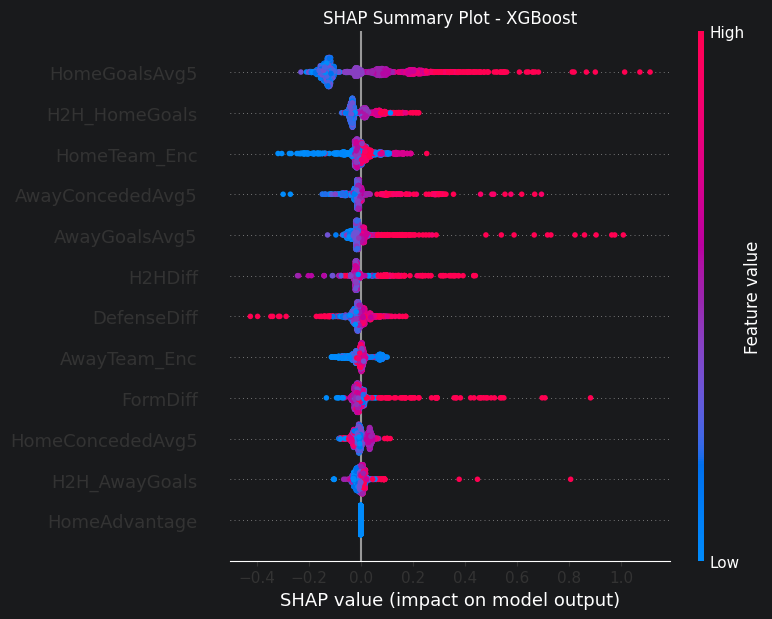

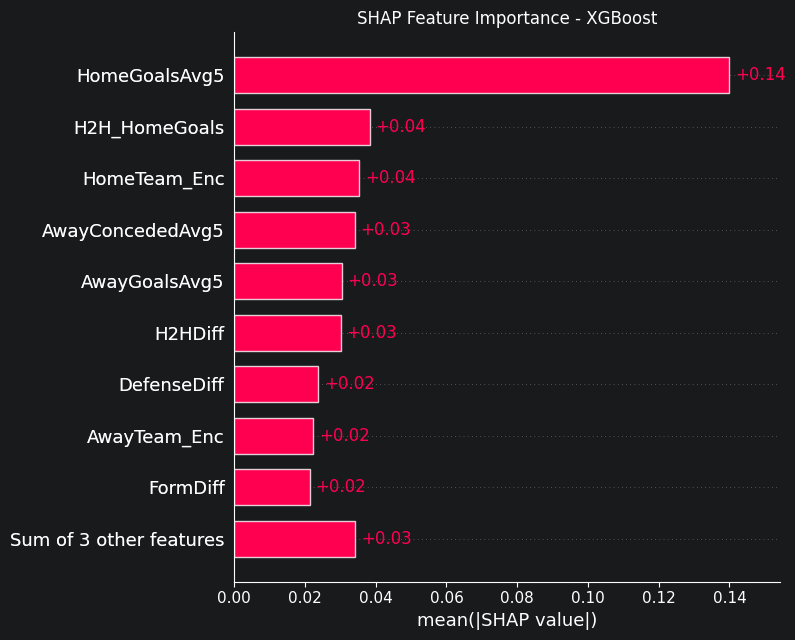

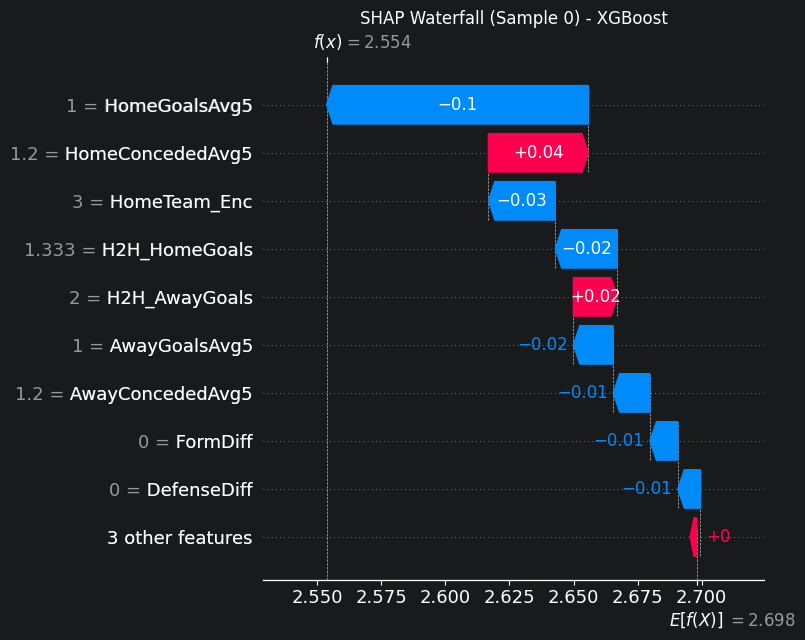

<Figure size 800x500 with 0 Axes>

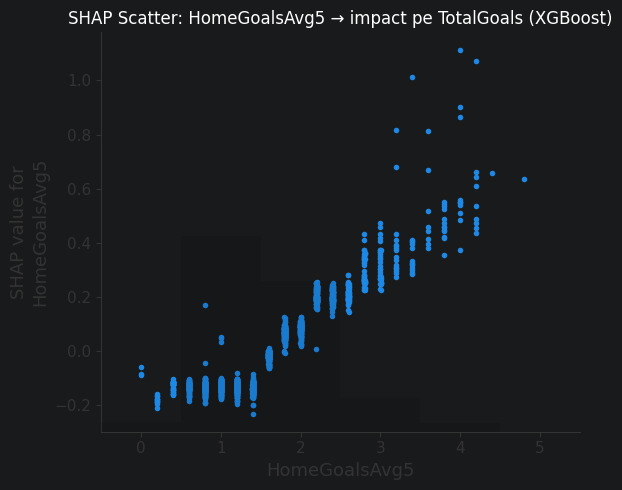

<Figure size 800x500 with 0 Axes>

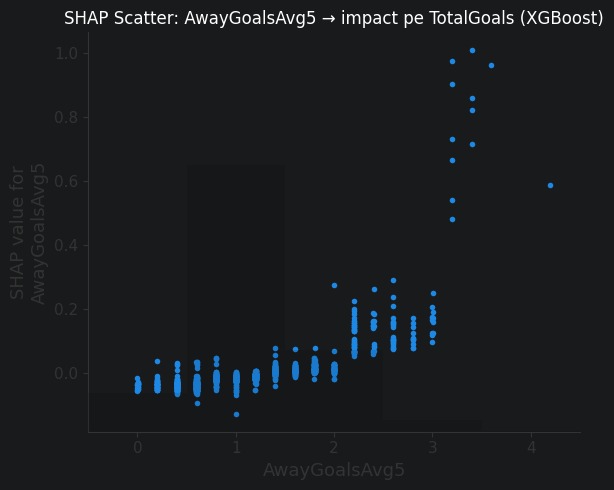

<Figure size 800x500 with 0 Axes>

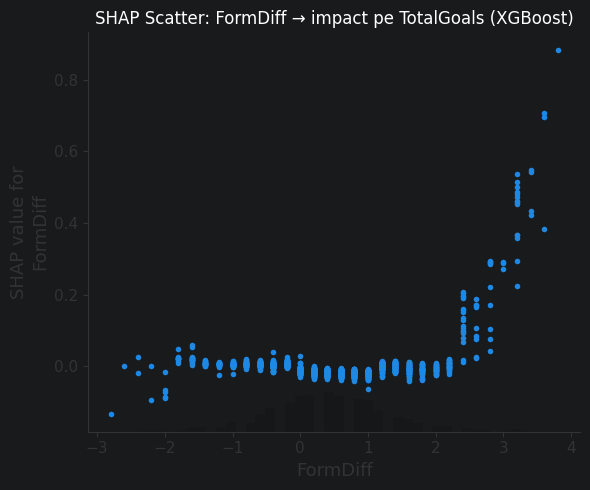


=== SHAP ANALYSIS FOR: RandomForest ===


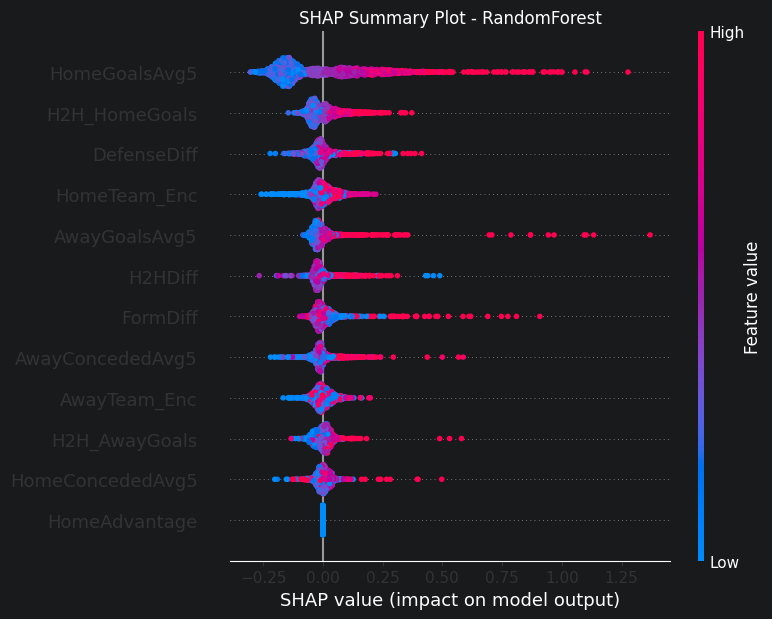

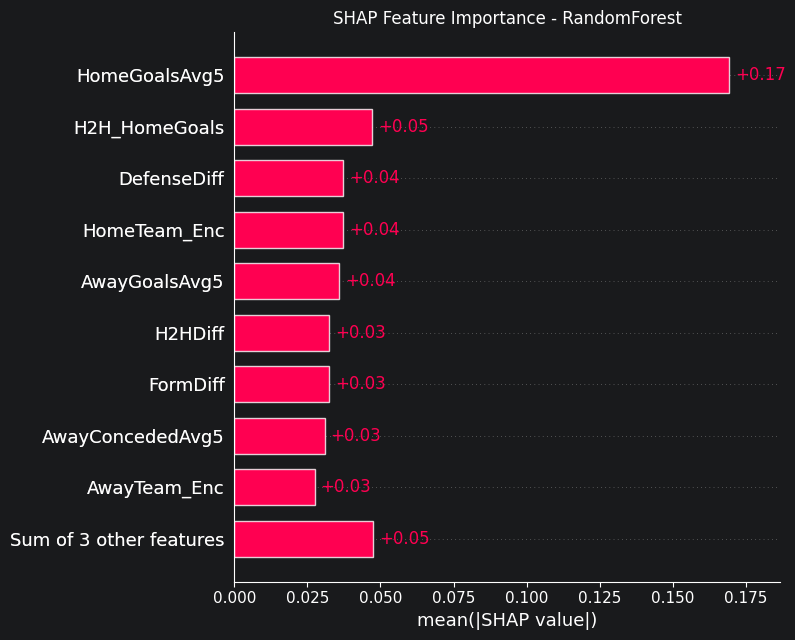

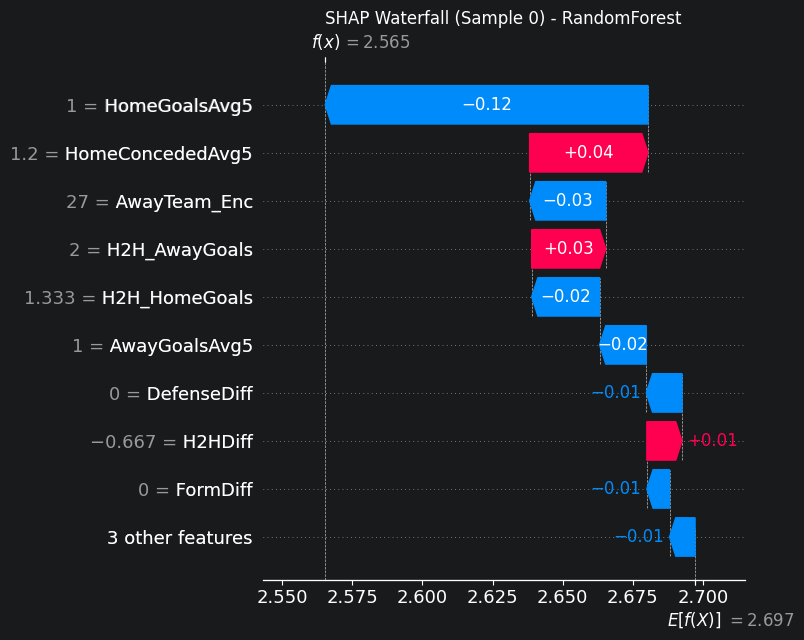

<Figure size 800x500 with 0 Axes>

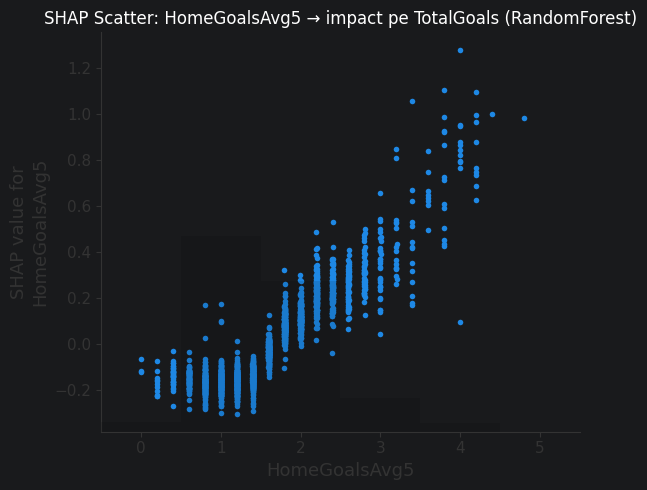

<Figure size 800x500 with 0 Axes>

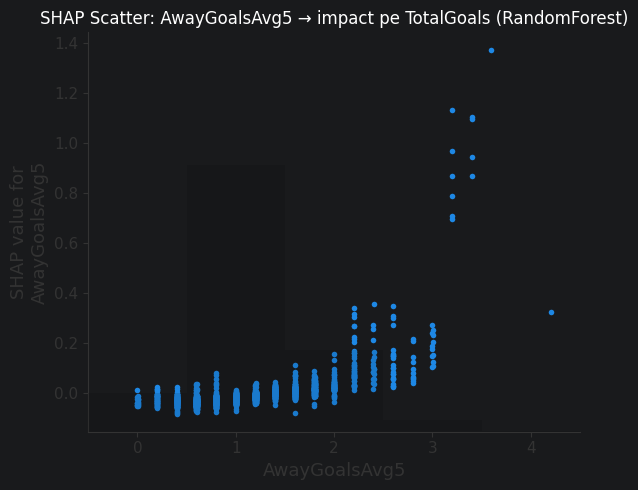

<Figure size 800x500 with 0 Axes>

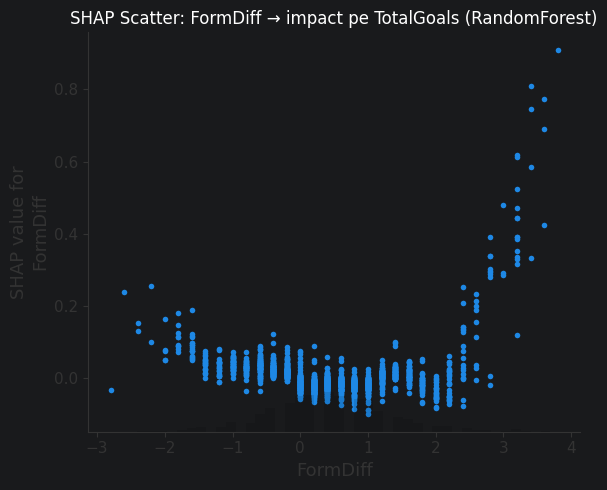

In [14]:
top_3_names = df_final['Model'].head(3).tolist()
SCATTER_FEATURES = ['HomeGoalsAvg5', 'AwayGoalsAvg5', 'FormDiff']
for name in top_3_names:
    print(f"\n=== SHAP ANALYSIS FOR: {name} ===")
    model = best_estimators[name]
    if hasattr(model, 'named_steps'):
        inner_model = model.named_steps['model']
        X_test_for_shap = pd.DataFrame(
            model.named_steps['scaler'].transform(X_test),
            columns=X_test.columns
        )
        X_train_for_shap = pd.DataFrame(
            model.named_steps['scaler'].transform(X_train),
            columns=X_train.columns
        )
    else:
        inner_model = model
        X_test_for_shap = X_test
        X_train_for_shap = X_train
    if name in ["CatBoost", "XGBoost", "RandomForest", "DecisionTree"]:
        explainer = shap.TreeExplainer(inner_model)
    elif name == "EBM":
        continue
    elif name == "LinearRegression":
        explainer = shap.LinearExplainer(inner_model, X_train_for_shap)
    else:
        explainer = shap.KernelExplainer(inner_model.predict, shap.sample(X_train_for_shap, 50))
    shap_values = explainer(X_test_for_shap)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_for_shap, show=False)
    plt.title(f"SHAP Summary Plot - {name}")
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_values, show=False)
    plt.title(f"SHAP Feature Importance - {name}")
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[0], show=False)
    plt.title(f"SHAP Waterfall (Sample 0) - {name}")
    plt.tight_layout()
    plt.show()
    for feat in SCATTER_FEATURES:
        if feat in X_test_for_shap.columns:
            plt.figure(figsize=(8, 5))
            shap.plots.scatter(shap_values[:, feat], show=False)
            plt.title(f"SHAP Scatter: {feat} → impact pe TotalGoals ({name})")
            plt.tight_layout()
            plt.show()